# 02. Comprehensive Exploratory Data Analysis & Statistical Profiling
**GitAI — Data-Driven GitHub Intelligence & Trend Prediction**

---

### Notebook Structure:
1. **Section 1: Data Loading & Quality Validation**
2. **Section 2: Data Cleaning Audit & Dictionary** (Historical record of Phase 4 Step 2)
3. **Section 3: Dataset Landscape & Macro Characteristics** (Languages, Ages, Licenses, Topics)
4. **Section 4: Popularity & Engagement Metric Distributions** (Stars, Forks, Issues, Skewness, Extreme Values)
5. **Section 5: Cross-Language Comparison** (Median/Mean Stars, Forks, Issues, and Age by Ecosystem)
6. **Section 6: Relationship & Correlation Analysis** (Stars vs. Forks, Stars vs. Issues, Age vs. Stars, Pearson vs. Spearman)
7. **Section 7: Topic Modeling & Tag Exploration** (Top 20 Topics, Language Breakdown, Popularity Differences)
8. **Section 8: Sampling Strata (Star Tier) Exploration**
9. **Section 9: Correlation Matrix & Statistical Summary**
10. **Section 10: Key EDA Findings & Machine Learning Implications**

> **Academic Guidelines:**
> - Non-causal framing (correlation $
eq$ causation).
> - All observations directly supported by empirical data ($N = 2,520$).
> - Outliers preserved and investigated.
> - Explicit warning against target leakage (`stars` $ightarrow$ `popularity_class`).


In [1]:
# 1. Imports and Environment Setup
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Resolve paths
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
cleaned_csv_path = project_root / "data" / "processed" / "github_repositories_cleaned.csv"

# Load cleaned dataset
df = pd.read_csv(cleaned_csv_path, keep_default_na=False)

# Parse datetimes
df["created_at_dt"] = pd.to_datetime(df["created_at"], utc=True)
df["updated_at_dt"] = pd.to_datetime(df["updated_at"], utc=True)
df["pushed_at_dt"] = pd.to_datetime(df["pushed_at"], utc=True)

# Derive baseline age features for EDA
reference_date = df["pushed_at_dt"].max()
df["repo_age_days"] = (reference_date - df["created_at_dt"]).dt.total_seconds() / 86400
df["repo_age_years"] = df["repo_age_days"] / 365.25
df["days_since_last_push"] = (reference_date - df["pushed_at_dt"]).dt.total_seconds() / 86400

# Parse topic list and topic count
df["topic_list"] = df["topics"].apply(lambda x: [t.strip() for t in str(x).split(",") if t.strip()] if x != "" else [])
df["topic_count"] = df["topic_list"].apply(len)
df["has_topics"] = df["topic_count"] > 0

print(f"Loaded cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total missing values across all columns: {df.isnull().sum().sum()}")


Loaded cleaned dataset: 2520 rows, 23 columns
Total missing values across all columns: 0


## Section A: Dataset Landscape & Macro Characteristics

Language Distribution:
language
JavaScript    252
TypeScript    252
Java          252
C++           252
C#            252
Go            252
Rust          252
Ruby          252
PHP           252
Python        251
Unknown         1
Name: count, dtype: int64


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/689261505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="viridis", ax=ax)


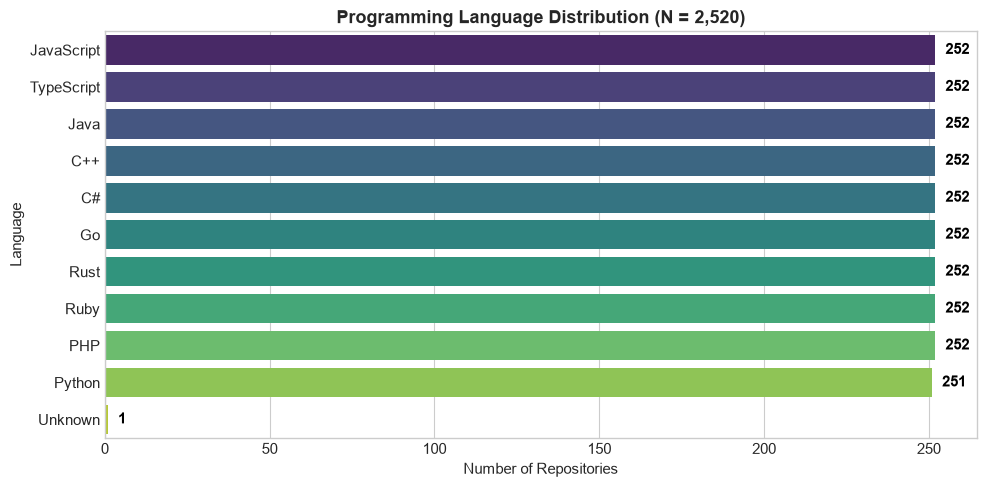

In [2]:
# 2.1 Language Representation
lang_counts = df["language"].value_counts()
print("Language Distribution:")
print(lang_counts)

# Visualizing Language Distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="viridis", ax=ax)
ax.set_title("Programming Language Distribution (N = 2,520)", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Repositories")
ax.set_ylabel("Language")
for i, v in enumerate(lang_counts.values):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/240469976.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=license_plot_data.values, y=license_plot_data.index, palette="mako", ax=ax)


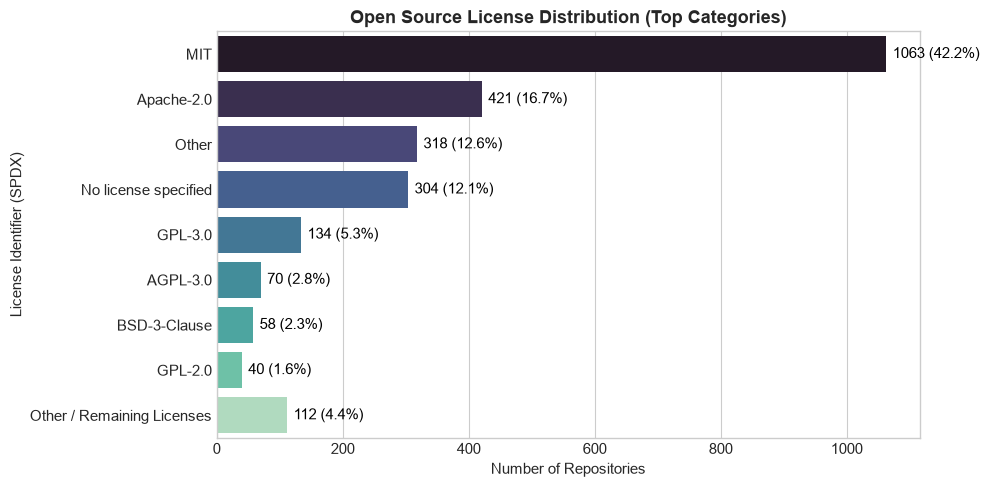

In [3]:
# 2.2 License Availability & Distribution
license_counts = df["license"].value_counts()
license_top8 = license_counts.head(8)
license_other = pd.Series({"Other / Remaining Licenses": license_counts.iloc[8:].sum()})
license_plot_data = pd.concat([license_top8, license_other])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=license_plot_data.values, y=license_plot_data.index, palette="mako", ax=ax)
ax.set_title("Open Source License Distribution (Top Categories)", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Repositories")
ax.set_ylabel("License Identifier (SPDX)")
for i, v in enumerate(license_plot_data.values):
    ax.text(v + 10, i, f"{v} ({v/len(df)*100:.1f}%)", color='black', va='center')
plt.tight_layout()
plt.show()


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/1130394728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="creation_year", palette="crest", ax=ax1)


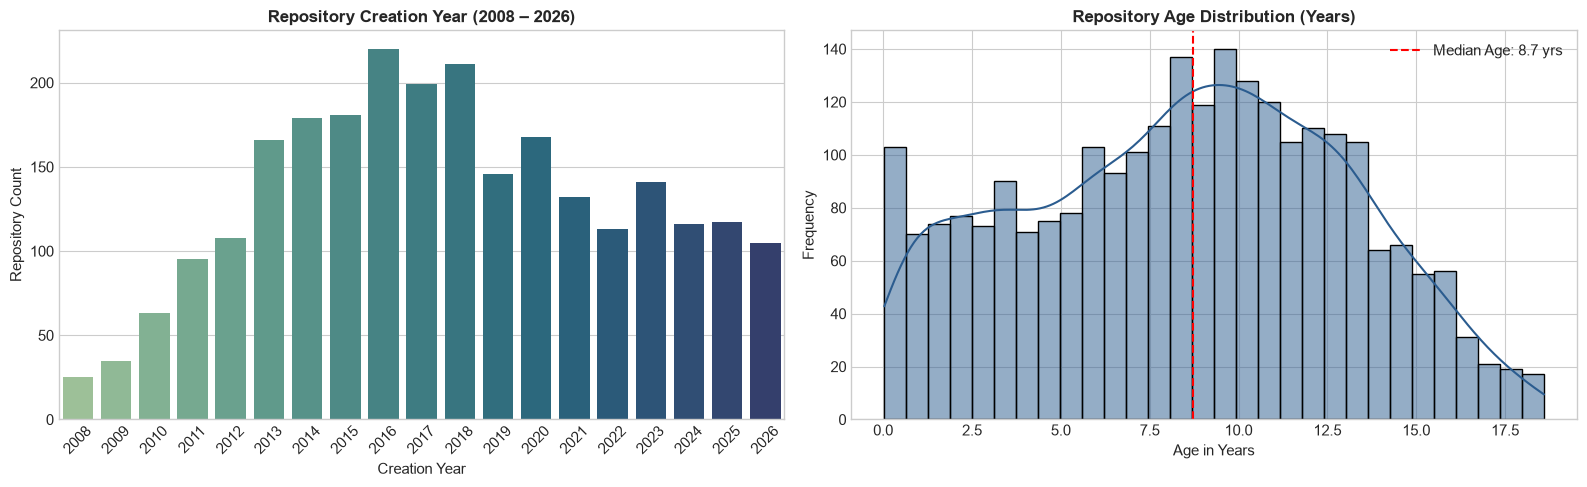

Earliest Creation Date: 2008-01-27
Latest Creation Date:   2026-08-20
Median Repository Age:  8.71 years (3181 days)


In [4]:
# 2.3 Creation Timeline & Repository Age Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Creation Year Distribution
df["creation_year"] = df["created_at_dt"].dt.year
sns.countplot(data=df, x="creation_year", palette="crest", ax=ax1)
ax1.set_title("Repository Creation Year (2008 – 2026)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Creation Year")
ax1.set_ylabel("Repository Count")
ax1.tick_params(axis='x', rotation=45)

# Subplot 2: Repository Age Distribution (Years)
sns.histplot(df["repo_age_years"], bins=30, kde=True, color="#2b5c8f", ax=ax2)
ax2.set_title("Repository Age Distribution (Years)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Age in Years")
ax2.set_ylabel("Frequency")
ax2.axvline(df["repo_age_years"].median(), color="red", linestyle="--", label=f"Median Age: {df['repo_age_years'].median():.1f} yrs")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Earliest Creation Date: {df['created_at_dt'].min().strftime('%Y-%m-%d')}")
print(f"Latest Creation Date:   {df['created_at_dt'].max().strftime('%Y-%m-%d')}")
print(f"Median Repository Age:  {df['repo_age_years'].median():.2f} years ({df['repo_age_days'].median():.0f} days)")


## Section B: Popularity & Engagement Metric Distributions

In [5]:
# 3.1 Numerical Metrics: Descriptive Statistics & Skewness Table
num_cols = ["stars", "forks", "open_issues"]
stats_records = []

for col in num_cols:
    s = df[col]
    q = s.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
    stats_records.append({
        "Metric": col,
        "Min": int(s.min()),
        "P10": int(q[0.10]),
        "P25": int(q[0.25]),
        "Median (P50)": float(q[0.50]),
        "Mean": round(s.mean(), 2),
        "P75": float(q[0.75]),
        "P90": float(q[0.90]),
        "P95": float(q[0.95]),
        "P99": float(q[0.99]),
        "Max": int(s.max()),
        "Std Dev": round(s.std(), 2),
        "Skewness": round(s.skew(), 2),
        "Kurtosis": round(s.kurt(), 2)
    })

stats_df = pd.DataFrame(stats_records).set_index("Metric")
print("DESCRIPTIVE STATISTICS & PERCENTILE BREAKDOWN:")
stats_df


DESCRIPTIVE STATISTICS & PERCENTILE BREAKDOWN:


,Min,P10,P25,Median (P50),Mean,P75,P90,P95,P99,Max,Std Dev,Skewness,Kurtosis
Metric,,,,,,,,,,,,,
stars,197,199,200,1960.0,18366.81,23771.50,60252.3,84698.2,174852.79,474001,38307.03,4.55,33.18
forks,0,20,56,231.0,2916.23,2227.75,8570.3,13513.8,38702.29,108793,7461.18,5.48,42.46
open_issues,0,1,6,27.0,323.32,136.25,664.3,1303.2,4955.16,38316,1496.47,14.83,297.49


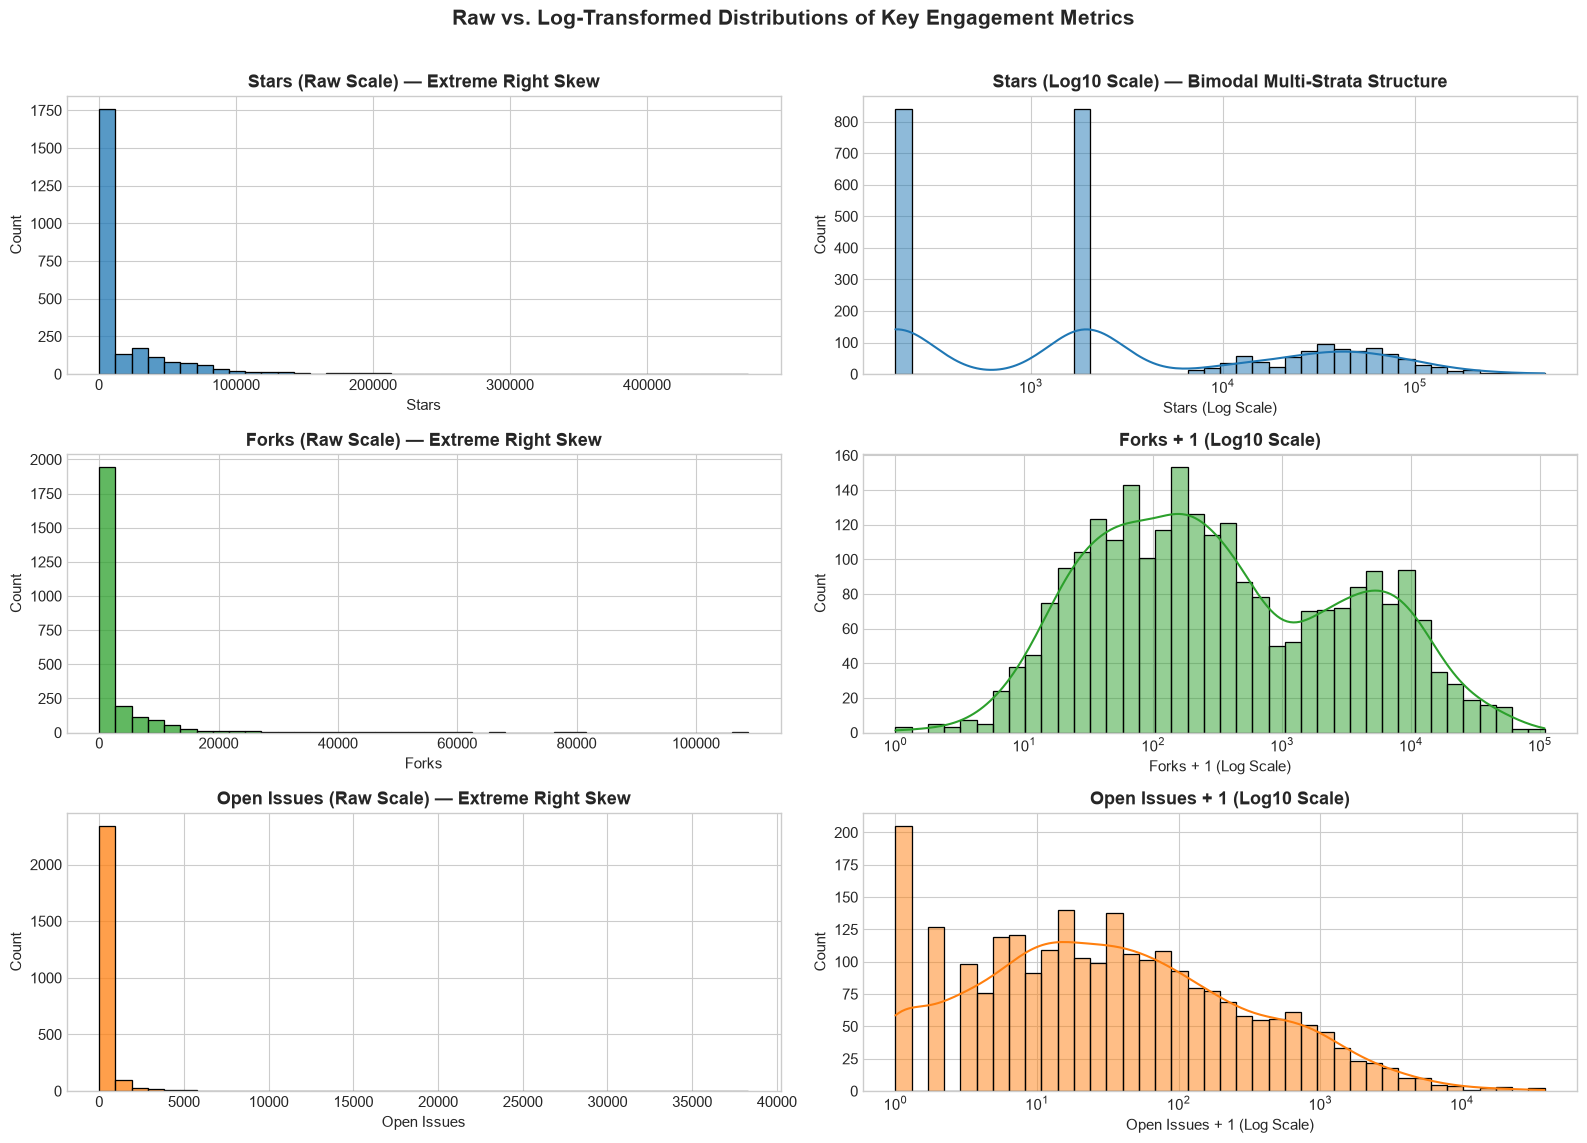

In [6]:
# 3.2 Visualizing Raw vs Log-Transformed Engagement Distributions
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Raw vs. Log-Transformed Distributions of Key Engagement Metrics", fontsize=15, fontweight='bold')

# Stars
sns.histplot(df["stars"], bins=40, color="#1f77b4", ax=axes[0, 0])
axes[0, 0].set_title("Stars (Raw Scale) — Extreme Right Skew", fontweight='bold')
axes[0, 0].set_xlabel("Stars")

sns.histplot(df["stars"], bins=40, kde=True, log_scale=True, color="#1f77b4", ax=axes[0, 1])
axes[0, 1].set_title("Stars (Log10 Scale) — Bimodal Multi-Strata Structure", fontweight='bold')
axes[0, 1].set_xlabel("Stars (Log Scale)")

# Forks
sns.histplot(df["forks"], bins=40, color="#2ca02c", ax=axes[1, 0])
axes[1, 0].set_title("Forks (Raw Scale) — Extreme Right Skew", fontweight='bold')
axes[1, 0].set_xlabel("Forks")

sns.histplot(df["forks"] + 1, bins=40, kde=True, log_scale=True, color="#2ca02c", ax=axes[1, 1])
axes[1, 1].set_title("Forks + 1 (Log10 Scale)", fontweight='bold')
axes[1, 1].set_xlabel("Forks + 1 (Log Scale)")

# Open Issues
sns.histplot(df["open_issues"], bins=40, color="#ff7f0e", ax=axes[2, 0])
axes[2, 0].set_title("Open Issues (Raw Scale) — Extreme Right Skew", fontweight='bold')
axes[2, 0].set_xlabel("Open Issues")

sns.histplot(df["open_issues"] + 1, bins=40, kde=True, log_scale=True, color="#ff7f0e", ax=axes[2, 1])
axes[2, 1].set_title("Open Issues + 1 (Log10 Scale)", fontweight='bold')
axes[2, 1].set_xlabel("Open Issues + 1 (Log Scale)")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


In [7]:
# 3.3 Genuine Extreme Value Inspection (Top 5 Outliers)
print("=" * 70)
print("CANONICAL EXTREME OBSERVATIONS (TOP 5 PER METRIC)")
print("=" * 70)
print("\nTop 5 Repositories by Stars:")
print(df.sort_values(by="stars", ascending=False)[["full_name", "language", "stars", "forks", "open_issues", "created_at"]].head(5).to_string(index=False))

print("\nTop 5 Repositories by Forks:")
print(df.sort_values(by="forks", ascending=False)[["full_name", "language", "stars", "forks", "open_issues", "created_at"]].head(5).to_string(index=False))

print("\nTop 5 Repositories by Open Issues:")
print(df.sort_values(by="open_issues", ascending=False)[["full_name", "language", "stars", "forks", "open_issues", "created_at"]].head(5).to_string(index=False))


CANONICAL EXTREME OBSERVATIONS (TOP 5 PER METRIC)

Top 5 Repositories by Stars:
                             full_name   language  stars  forks  open_issues           created_at
               public-apis/public-apis     Python 474001  52337         1852 2016-03-20T23:49:42Z
             freeCodeCamp/freeCodeCamp TypeScript 454817  46105          227 2014-12-24T17:49:19Z
EbookFoundation/free-programming-books     Python 395713  66723           82 2013-10-11T06:50:37Z
                     openclaw/openclaw TypeScript 388422  81539         5936 2025-11-24T10:16:47Z
      donnemartin/system-design-primer     Python 367144  58158          612 2017-02-26T16:15:28Z

Top 5 Repositories by Forks:
                             full_name   language  stars  forks  open_issues           created_at
                ultraworkers/claw-code       Rust 195163 108793           41 2026-03-31T08:58:08Z
                     openclaw/openclaw TypeScript 388422  81539         5936 2025-11-24T10:16:47Z
        

## Section C: Programming Language Popularity & Metrics Comparison

In [8]:
# 4.1 Cross-Language Engagement Comparison Table
lang_metrics = df[df["language"] != "Unknown"].groupby("language").agg(
    Repository_Count=("id", "count"),
    Median_Stars=("stars", "median"),
    Mean_Stars=("stars", lambda x: round(x.mean(), 1)),
    Median_Forks=("forks", "median"),
    Mean_Forks=("forks", lambda x: round(x.mean(), 1)),
    Median_Open_Issues=("open_issues", "median"),
    Mean_Open_Issues=("open_issues", lambda x: round(x.mean(), 1)),
    Median_Age_Years=("repo_age_years", lambda x: round(x.median(), 2))
).reset_index()

# Sort by Mean Stars descending
lang_metrics = lang_metrics.sort_values(by="Mean_Stars", ascending=False).reset_index(drop=True)
print("Cross-Language Metrics Comparison (Sorted by Mean Stars):")
lang_metrics


Cross-Language Metrics Comparison (Sorted by Mean Stars):


,language,Repository_Count,Median_Stars,Mean_Stars,Median_Forks,Mean_Forks,Median_Open_Issues,Mean_Open_Issues,Median_Age_Years
0,Python,251,1987.0,39225.3,216.0,6300.2,34.0,579.6,5.58
1,TypeScript,252,1977.5,32963.7,205.5,4745.8,25.0,545.6,4.85
2,JavaScript,252,1981.0,24703.0,212.5,3984.7,25.0,179.0,9.75
3,Go,252,1951.0,19058.6,191.0,2257.4,27.5,360.4,7.94
4,Rust,252,1941.0,17972.1,114.5,1761.1,42.0,460.3,5.16
5,C++,252,1950.0,15349.0,279.5,2750.7,41.0,422.6,9.05
6,Java,252,1956.5,13749.9,401.0,3649.1,26.5,245.1,9.78
7,C#,252,1921.0,7880.4,294.0,1403.7,30.0,224.9,8.46
8,PHP,252,1908.5,6516.3,268.5,1184.1,14.0,119.8,12.05
9,Ruby,252,1842.5,6404.6,220.0,1150.4,20.0,98.2,13.62


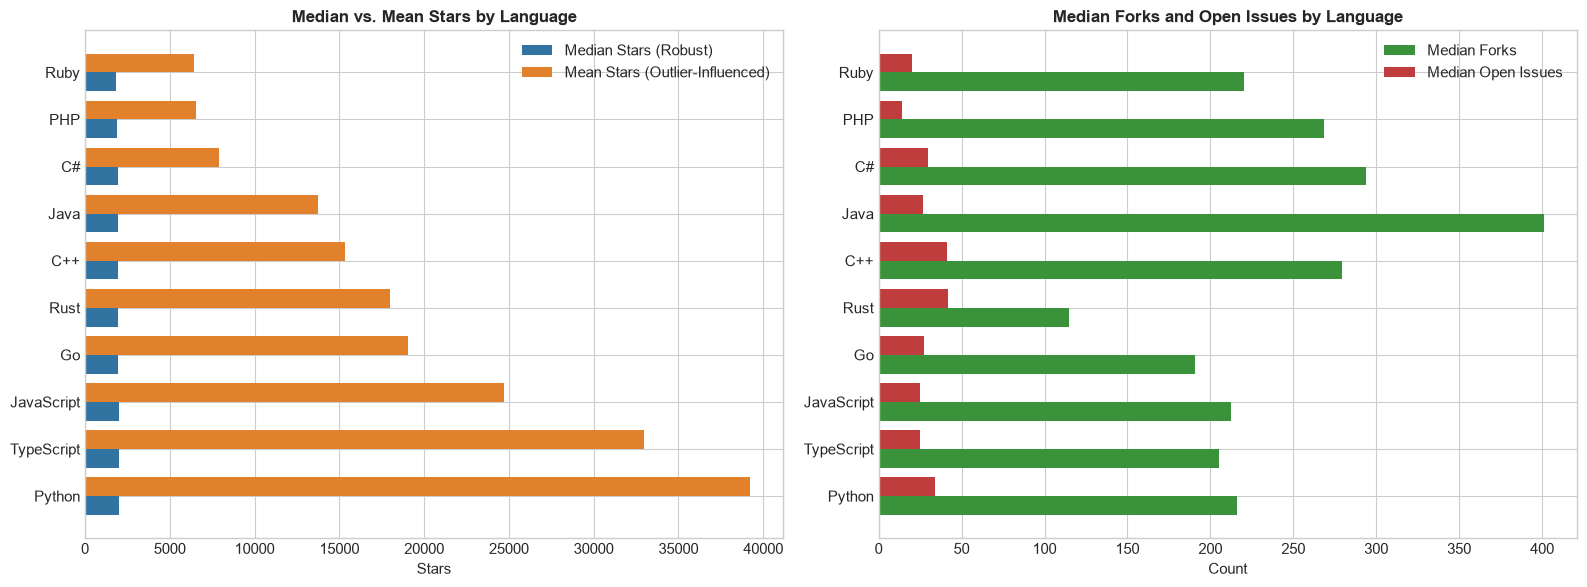

In [9]:
# 4.2 Visualizing Language Differences (Median vs Mean Stars & Forks)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Median vs Mean Stars by Language
lang_plot_order = lang_metrics.sort_values(by="Median_Stars", ascending=True)["language"]
y_indices = np.arange(len(lang_metrics))

ax1.barh(y_indices - 0.2, lang_metrics["Median_Stars"], height=0.4, label="Median Stars (Robust)", color="#3274A1")
ax1.barh(y_indices + 0.2, lang_metrics["Mean_Stars"], height=0.4, label="Mean Stars (Outlier-Influenced)", color="#E1812C")
ax1.set_yticks(y_indices)
ax1.set_yticklabels(lang_metrics["language"])
ax1.set_title("Median vs. Mean Stars by Language", fontsize=12, fontweight='bold')
ax1.set_xlabel("Stars")
ax1.legend()

# Plot 2: Median Forks & Issues by Language
ax2.barh(y_indices - 0.2, lang_metrics["Median_Forks"], height=0.4, label="Median Forks", color="#3A923A")
ax2.barh(y_indices + 0.2, lang_metrics["Median_Open_Issues"], height=0.4, label="Median Open Issues", color="#C03D3E")
ax2.set_yticks(y_indices)
ax2.set_yticklabels(lang_metrics["language"])
ax2.set_title("Median Forks and Open Issues by Language", fontsize=12, fontweight='bold')
ax2.set_xlabel("Count")
ax2.legend()

plt.tight_layout()
plt.show()


## Section D: Metric Relationships & Correlation Analysis

In [10]:
# 5.1 Correlation Comparison: Linear (Pearson) vs Rank (Spearman)
corr_cols = ["stars", "forks", "open_issues", "repo_age_days", "days_since_last_push", "topic_count"]

pearson_corr = df[corr_cols].corr(method="pearson").round(3)
spearman_corr = df[corr_cols].corr(method="spearman").round(3)

print("=" * 60)
print("PEARSON CORRELATION MATRIX (Linear Relationships)")
print("=" * 60)
print(pearson_corr)

print("\n" + "=" * 60)
print("SPEARMAN RANK CORRELATION MATRIX (Monotonic / Non-Parametric)")
print("=" * 60)
print(spearman_corr)


PEARSON CORRELATION MATRIX (Linear Relationships)
                      stars  forks  open_issues  repo_age_days  \
stars                 1.000  0.799        0.338         -0.052   
forks                 0.799  1.000        0.324          0.030   
open_issues           0.338  0.324        1.000         -0.006   
repo_age_days        -0.052  0.030       -0.006          1.000   
days_since_last_push -0.258 -0.204       -0.120          0.271   
topic_count           0.272  0.184        0.083         -0.159   

                      days_since_last_push  topic_count  
stars                               -0.258        0.272  
forks                               -0.204        0.184  
open_issues                         -0.120        0.083  
repo_age_days                        0.271       -0.159  
days_since_last_push                 1.000       -0.336  
topic_count                         -0.336        1.000  

SPEARMAN RANK CORRELATION MATRIX (Monotonic / Non-Parametric)
                  

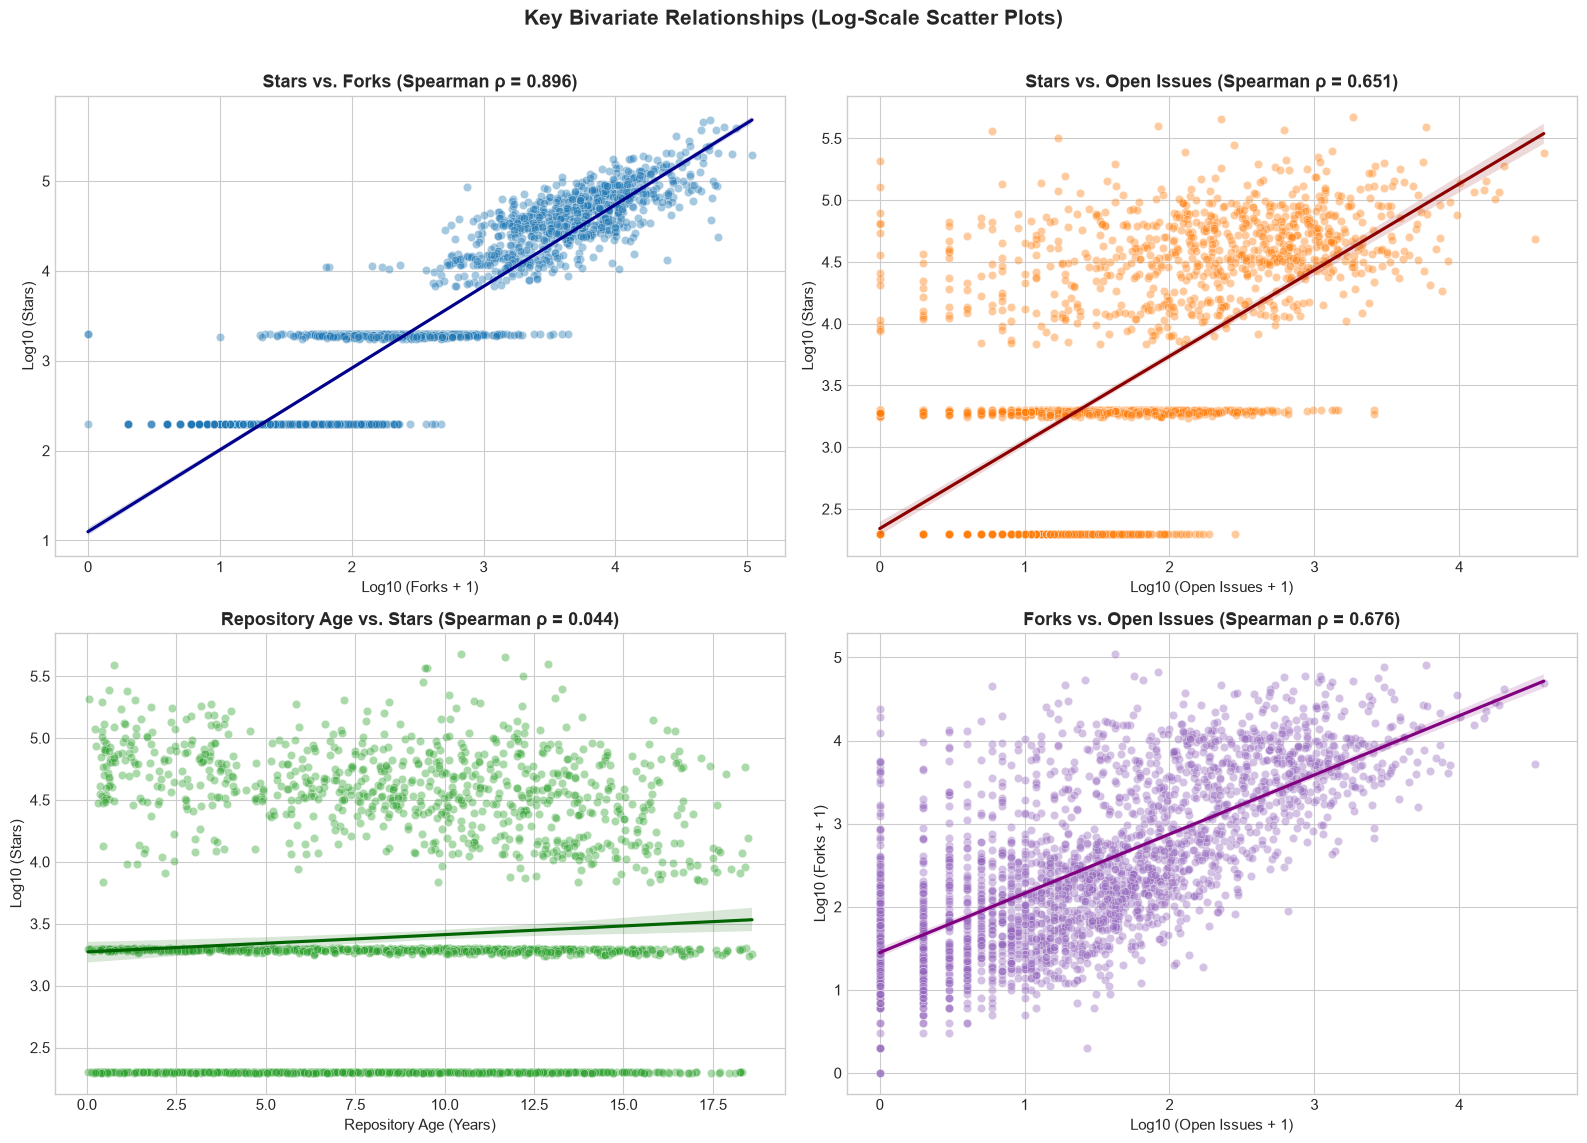

In [11]:
# 5.2 Visualizing Metric Relationships (Log-Scale Scatter Plots)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Key Bivariate Relationships (Log-Scale Scatter Plots)", fontsize=15, fontweight='bold')

# Plot 1: Stars vs Forks
sns.scatterplot(
    data=df,
    x=np.log10(df["forks"] + 1),
    y=np.log10(df["stars"]),
    alpha=0.4,
    color="#1f77b4",
    ax=axes[0, 0]
)
sns.regplot(
    data=df,
    x=np.log10(df["forks"] + 1),
    y=np.log10(df["stars"]),
    scatter=False,
    color="darkblue",
    ax=axes[0, 0]
)
axes[0, 0].set_title(f"Stars vs. Forks (Spearman ρ = {spearman_corr.loc['stars', 'forks']:.3f})", fontweight='bold')
axes[0, 0].set_xlabel("Log10 (Forks + 1)")
axes[0, 0].set_ylabel("Log10 (Stars)")

# Plot 2: Stars vs Open Issues
sns.scatterplot(
    data=df,
    x=np.log10(df["open_issues"] + 1),
    y=np.log10(df["stars"]),
    alpha=0.4,
    color="#ff7f0e",
    ax=axes[0, 1]
)
sns.regplot(
    data=df,
    x=np.log10(df["open_issues"] + 1),
    y=np.log10(df["stars"]),
    scatter=False,
    color="darkred",
    ax=axes[0, 1]
)
axes[0, 1].set_title(f"Stars vs. Open Issues (Spearman ρ = {spearman_corr.loc['stars', 'open_issues']:.3f})", fontweight='bold')
axes[0, 1].set_xlabel("Log10 (Open Issues + 1)")
axes[0, 1].set_ylabel("Log10 (Stars)")

# Plot 3: Repository Age vs Stars
sns.scatterplot(
    data=df,
    x=df["repo_age_years"],
    y=np.log10(df["stars"]),
    alpha=0.4,
    color="#2ca02c",
    ax=axes[1, 0]
)
sns.regplot(
    data=df,
    x=df["repo_age_years"],
    y=np.log10(df["stars"]),
    scatter=False,
    color="darkgreen",
    ax=axes[1, 0]
)
axes[1, 0].set_title(f"Repository Age vs. Stars (Spearman ρ = {spearman_corr.loc['stars', 'repo_age_days']:.3f})", fontweight='bold')
axes[1, 0].set_xlabel("Repository Age (Years)")
axes[1, 0].set_ylabel("Log10 (Stars)")

# Plot 4: Forks vs Open Issues
sns.scatterplot(
    data=df,
    x=np.log10(df["open_issues"] + 1),
    y=np.log10(df["forks"] + 1),
    alpha=0.4,
    color="#9467bd",
    ax=axes[1, 1]
)
sns.regplot(
    data=df,
    x=np.log10(df["open_issues"] + 1),
    y=np.log10(df["forks"] + 1),
    scatter=False,
    color="purple",
    ax=axes[1, 1]
)
axes[1, 1].set_title(f"Forks vs. Open Issues (Spearman ρ = {spearman_corr.loc['forks', 'open_issues']:.3f})", fontweight='bold')
axes[1, 1].set_xlabel("Log10 (Open Issues + 1)")
axes[1, 1].set_ylabel("Log10 (Forks + 1)")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


## Section E: Topic & Ecosystem Tag Analysis

/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/2789006220.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_topics.values, y=top20_topics.index, palette="rocket", ax=ax)


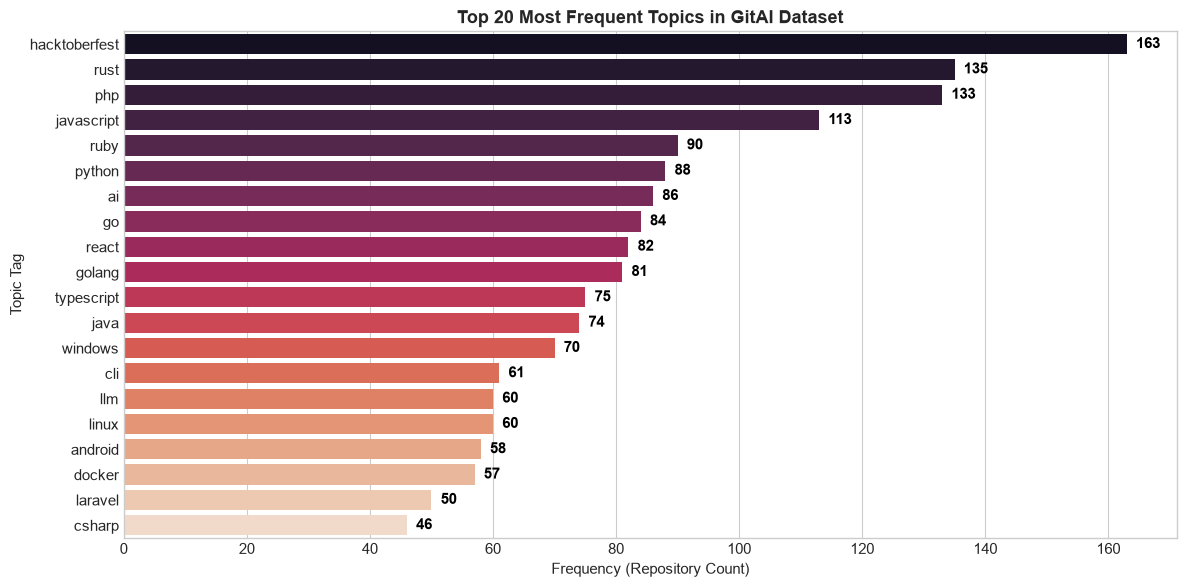

In [12]:
# 6.1 Top 20 Most Frequent Topics Across the Dataset
all_tags_list = [tag for sublist in df["topic_list"] for tag in sublist]
top20_topics = pd.Series(all_tags_list).value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=top20_topics.values, y=top20_topics.index, palette="rocket", ax=ax)
ax.set_title("Top 20 Most Frequent Topics in GitAI Dataset", fontsize=13, fontweight='bold')
ax.set_xlabel("Frequency (Repository Count)")
ax.set_ylabel("Topic Tag")
for i, v in enumerate(top20_topics.values):
    ax.text(v + 1.5, i, str(v), color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# 6.2 Topic Availability vs. Engagement Statistics
topic_presence_summary = df.groupby("has_topics").agg(
    Repository_Count=("id", "count"),
    Median_Stars=("stars", "median"),
    Mean_Stars=("stars", lambda x: round(x.mean(), 1)),
    Median_Forks=("forks", "median"),
    Median_Issues=("open_issues", "median"),
    Median_Age_Years=("repo_age_years", lambda x: round(x.median(), 2))
).reset_index()

topic_presence_summary["has_topics"] = topic_presence_summary["has_topics"].map({True: "With Topics (>=1)", False: "No Topics (0)"})
print("Topic Tag Presence vs. Engagement Metrics:")
topic_presence_summary


Topic Tag Presence vs. Engagement Metrics:


,has_topics,Repository_Count,Median_Stars,Mean_Stars,Median_Forks,Median_Issues,Median_Age_Years
0,No Topics (0),843,200.0,6635.9,89.0,13.0,9.34
1,With Topics (>=1),1677,1985.0,24263.7,412.0,42.0,8.52


## Section F: Sampling Strata (Star-Tier) Exploratory Comparison

In [14]:
# 7.1 Stratified Tier Comparison
def assign_strata(s):
    if s <= 200:
        return "1. Low (10–200)"
    elif s <= 2000:
        return "2. Mid (201–2,000)"
    else:
        return "3. High (>2,000)"

df["sampling_tier"] = df["stars"].apply(assign_strata)

strata_summary = df.groupby("sampling_tier").agg(
    Repository_Count=("id", "count"),
    Median_Stars=("stars", "median"),
    Median_Forks=("forks", "median"),
    Mean_Forks=("forks", lambda x: round(x.mean(), 1)),
    Median_Open_Issues=("open_issues", "median"),
    Mean_Open_Issues=("open_issues", lambda x: round(x.mean(), 1)),
    Median_Age_Years=("repo_age_years", lambda x: round(x.median(), 2)),
    Median_Topic_Count=("topic_count", "median"),
    Mean_Topic_Count=("topic_count", lambda x: round(x.mean(), 2))
).reset_index()

print("SAMPLING STRATA EXPLORATORY METRICS:")
strata_summary


SAMPLING STRATA EXPLORATORY METRICS:


,sampling_tier,Repository_Count,Median_Stars,Median_Forks,Mean_Forks,Median_Open_Issues,Mean_Open_Issues,Median_Age_Years,Median_Topic_Count,Mean_Topic_Count
0,1. Low (10–200),840,200.0,33.5,47.9,5.0,13.3,7.82,0.0,3.07
1,"2. Mid (201–2,000)",840,1960.0,232.0,329.0,30.0,73.4,9.06,4.0,5.25
2,"3. High (>2,000)",840,39009.5,4886.0,8371.8,241.0,883.3,9.60,7.0,8.37


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/2253359110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sampling_tier", y=np.log10(df["forks"] + 1), palette="Set2", ax=ax1)
/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/2253359110.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sampling_tier", y=np.log10(df["open_issues"] + 1), palette="Set2", ax=ax2)


/var/folders/ts/kxqrt_dd41n1kzf_84byngbc0000gn/T/ipykernel_26868/2253359110.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sampling_tier", y="topic_count", palette="Set2", ax=ax3)


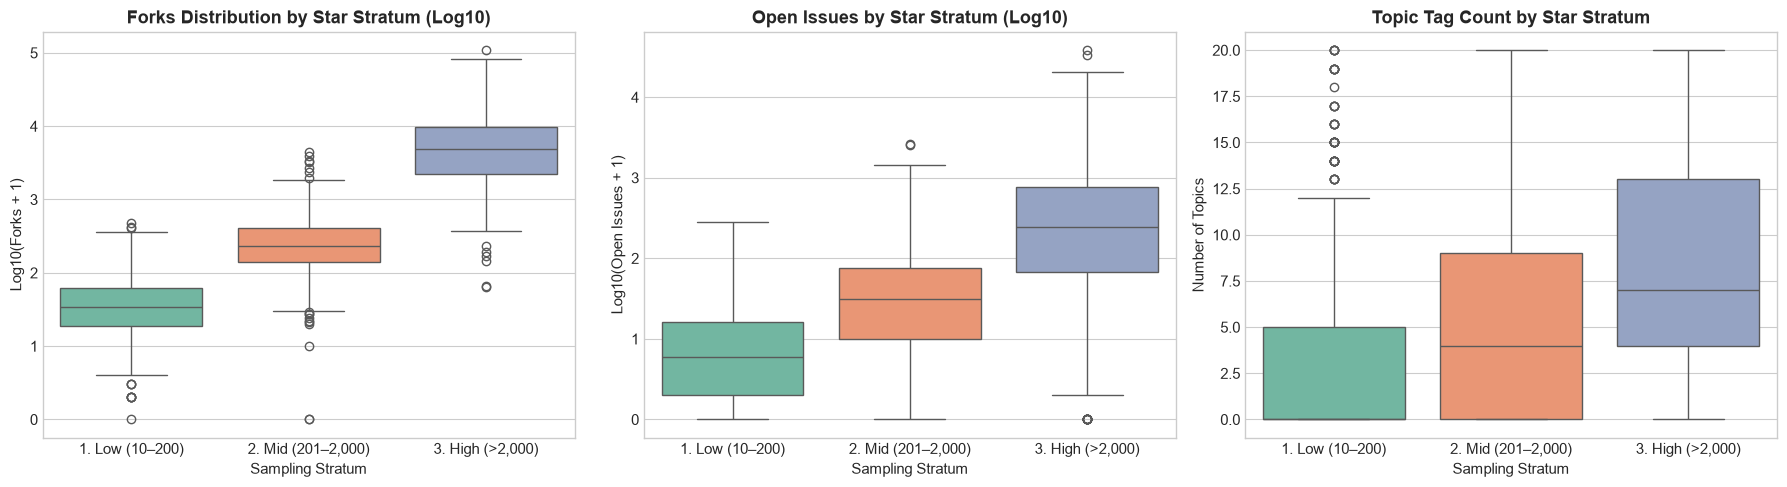

In [15]:
# 7.2 Visualizing Strata Differences
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Forks by Strata
sns.boxplot(data=df, x="sampling_tier", y=np.log10(df["forks"] + 1), palette="Set2", ax=ax1)
ax1.set_title("Forks Distribution by Star Stratum (Log10)", fontweight='bold')
ax1.set_xlabel("Sampling Stratum")
ax1.set_ylabel("Log10(Forks + 1)")

# Open Issues by Strata
sns.boxplot(data=df, x="sampling_tier", y=np.log10(df["open_issues"] + 1), palette="Set2", ax=ax2)
ax2.set_title("Open Issues by Star Stratum (Log10)", fontweight='bold')
ax2.set_xlabel("Sampling Stratum")
ax2.set_ylabel("Log10(Open Issues + 1)")

# Topic Count by Strata
sns.boxplot(data=df, x="sampling_tier", y="topic_count", palette="Set2", ax=ax3)
ax3.set_title("Topic Tag Count by Star Stratum", fontweight='bold')
ax3.set_xlabel("Sampling Stratum")
ax3.set_ylabel("Number of Topics")

plt.tight_layout()
plt.show()


## Section G: Statistical Summary & Correlation Heatmap

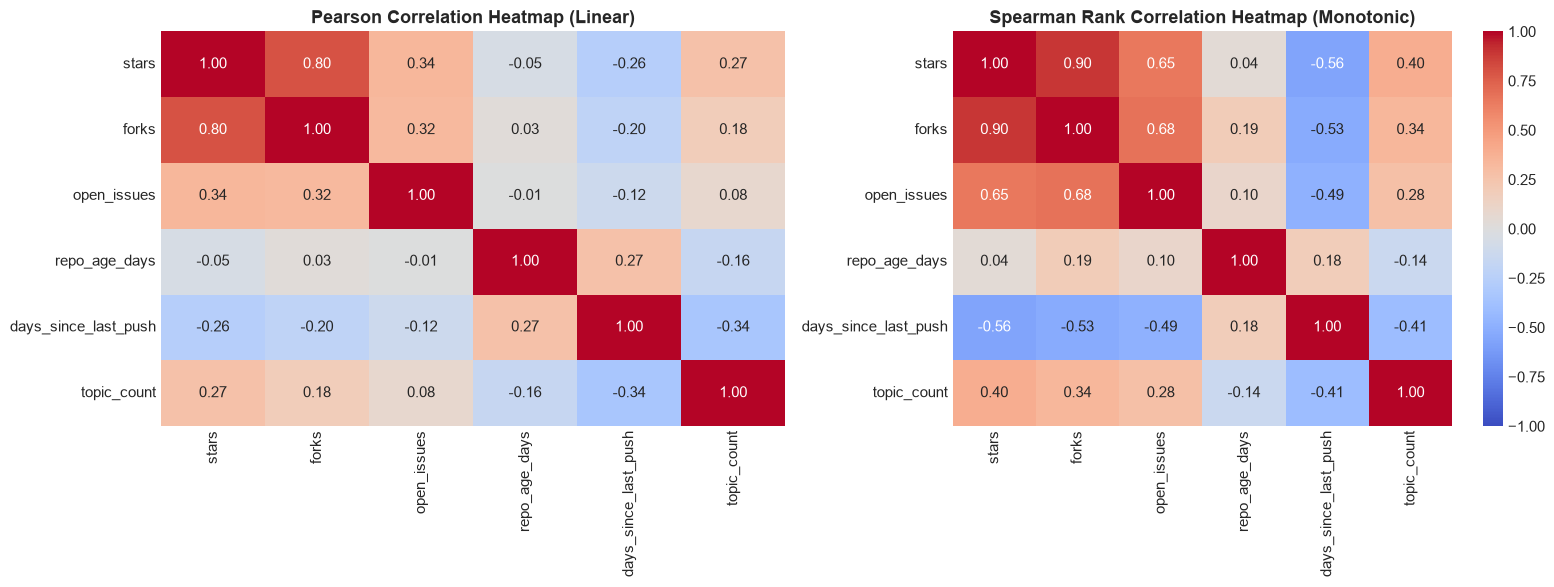

In [16]:
# 8.1 Correlation Heatmaps (Pearson vs. Spearman)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=ax1, cbar=False)
ax1.set_title("Pearson Correlation Heatmap (Linear)", fontsize=13, fontweight='bold')

sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=ax2)
ax2.set_title("Spearman Rank Correlation Heatmap (Monotonic)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## Section H: Key EDA Findings & Implications for Machine Learning

### 1. Key EDA Findings (Evidence-Based Observations):

1. **Engagement Metrics Exhibit Severe Non-Normal Right Skewness**:
   - `stars` ($	ext{skew} = +4.55$, $	ext{median} = 1,960$, $	ext{max} = 474,001$).
   - `forks` ($	ext{skew} = +5.48$, $	ext{median} = 231$, $	ext{max} = 108,793$).
   - `open_issues` ($	ext{skew} = +14.83$, $	ext{median} = 27$, $	ext{max} = 38,316$).
   - Logarithmic transformation ($\log_{10}(x + 1)$) normalizes the metric spread and reveals strong underlying monotonic relationships.

2. **High Monotonic Correlation Between Stars and Forks**:
   - Spearman rank correlation between `stars` and `forks` is **$ho = 0.896$** (Pearson $r = 0.799$).
   - Repositories with higher star counts consistently tend to have proportionally higher fork counts across all 10 languages.

3. **Moderate Monotonic Correlation with Open Issues**:
   - Spearman correlation between `stars` and `open_issues` is **$ho = 0.651$**.
   - Larger/more active projects accumulate larger backlogs of community issues and PRs.

4. **Weak Direct Correlation Between Age and Popularity**:
   - `repo_age_days` exhibits near-zero linear correlation ($r = -0.052$) and weak rank correlation ($ho = 0.044$) with raw stars.
   - Older repositories do not automatically have more stars; newer high-velocity frameworks can rapidly achieve high popularity while legacy inactive repos remain stagnant.

5. **Topic Availability Aligns with Higher Community Activity**:
   - 66.55% ($N=1,677$) of repositories have $\ge 1$ topic tag, while 33.45% ($N=843$) have none.
   - Repositories with topics have a **median of 1,985 stars and 412 forks**, compared to **200 stars and 89 forks** for repositories without topic tags.

6. **Language-Level Variance**:
   - Python and TypeScript have the highest mean stars ($39,225$ and $32,964$) due to mega-repositories, while Ruby and PHP repositories in the dataset tend to have older median ages ($13.6$ and $12.1$ years) with lower recent push velocity.

---

### 2. Implications for Machine Learning:

> [!WARNING]
> **CRITICAL TARGET LEAKAGE RULE:**
> If the machine learning task is predicting repository `popularity_class` defined from `stars` (e.g., top-25% threshold or binary cut), **`stars` must NOT be used as an input feature**. Any derivative of stars (such as `fork_to_star_ratio` or `stars_per_year`) would also cause immediate target leakage and must be strictly avoided as predictive inputs.

#### Candidate Predictive Features for Modeling:
1. **Activity & Engagement Proxies**:
   - `forks` ($\log_{1p}$-transformed): Strongest legitimate predictor of repository adoption ($ho = 0.896$ with stars).
   - `open_issues` ($\log_{1p}$-transformed): Strong indicator of project scale, user base, and active contributions ($ho = 0.651$).
2. **Temporal Features**:
   - `repo_age_days` / `repo_age_years`: Lifespan metric.
   - `days_since_last_push` ($\log_{1p}$): Measures recent maintenance recency.
   - `issues_per_year` ($	ext{open\_issues} / 	ext{age}$): Rate of issue generation.
   - `forks_per_year` ($	ext{forks} / 	ext{age}$): Annualized fork velocity.
3. **Metadata & Categorical Features**:
   - `topic_count`: Count of topic tags (positive monotonic association).
   - `has_description`: Binary indicator (presence of documentation).
   - `description_length`: Character length of repository description.
   - `has_license`: Binary indicator (licensed vs unlicensed).
   - `language` (One-Hot Encoded): Captures ecosystem-specific baseline activity.
4. **Transformations Required**:
   - Non-linear algorithms (Random Forest, XGBoost) will naturally handle feature monotonicities, while linear models (Logistic Regression) will require $\log_{1p}$ transforms and standard scaling (`StandardScaler`).
